In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
from torch.utils.data import DataLoader, Dataset

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class AlbaniaSATDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), \
               torch.tensor(self.y[idx], dtype=torch.long)

class_names = [
    "Broad-leaved Forest", "Coniferous Forest", "Shrubland",
    "Agricultural", "Grassland", "Olive Groves", "Urban", "Water"
]

eurosat_classes = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]

Using device: mps


In [2]:
X = np.load("../data/AlbaniaSAT/processed_v2/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v2/labels.npy")

# Split — same seed as training
n = len(X)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
test_idx = indices[n_train + n_val:]

# RGB test set (3 bands)
X_rgb = X[:, :3, :, :]
X_rgb = np.clip(X_rgb, 0, 3000) / 3000.0
mean_3 = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
std_3  = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)
X_rgb = (X_rgb - mean_3) / std_3
X_rgb = X_rgb.astype(np.float32)

# 4-band test set
X_4band = X[:, :4, :, :]
X_4band = np.clip(X_4band, 0, 3000) / 3000.0
mean_4 = np.array([0.485, 0.456, 0.406, 0.441]).reshape(1, 4, 1, 1)
std_4  = np.array([0.229, 0.224, 0.225, 0.220]).reshape(1, 4, 1, 1)
X_4band = (X_4band - mean_4) / std_4
X_4band = X_4band.astype(np.float32)

# Test loaders
test_rgb  = DataLoader(AlbaniaSATDataset(X_rgb[test_idx],   y[test_idx]), batch_size=32)
test_4band = DataLoader(AlbaniaSATDataset(X_4band[test_idx], y[test_idx]), batch_size=32)

print(f"Test set size: {len(test_idx)} patches")

Test set size: 1200 patches


In [3]:
def evaluate(model, loader, model_name):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    acc = correct / total * 100
    print(f"{model_name}: {acc:.2f}%")
    return acc

In [4]:
results = {}

# Model 1 — EuroSAT ResNet50 zero-shot
eurosat_ckpt = torch.load("../results/models/resnet50_eurosat.pth", map_location="cpu")
model_eurosat = models.resnet50()
model_eurosat.fc = nn.Linear(2048, 10)
model_eurosat.load_state_dict(eurosat_ckpt)
model_eurosat = model_eurosat.to(device)

# Map AlbaniaSAT labels to closest EuroSAT equivalent
mapping = {0:1, 1:1, 2:2, 3:0, 4:5, 5:6, 6:7, 7:9}
y_test = y[test_idx]
y_eurosat_equiv = np.array([mapping[label] for label in y_test])

model_eurosat.eval()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_rgb:
        X_batch = X_batch.to(device)
        preds = model_eurosat(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
all_preds = np.array(all_preds)
acc_eurosat = (all_preds == y_eurosat_equiv).mean() * 100
print(f"EuroSAT zero-shot: {acc_eurosat:.2f}%")
results["EuroSAT zero-shot (RGB)"] = acc_eurosat

# Model 2 — ResNet50 finetuned on AlbaniaSAT v2 RGB
model_ft = models.resnet50()
model_ft.fc = nn.Linear(2048, 8)
model_ft.load_state_dict(torch.load("../results/models/resnet50_albaniasat_v2.pth", map_location="cpu"))
model_ft = model_ft.to(device)
results["ResNet50 finetuned (RGB)"] = evaluate(model_ft, test_rgb, "ResNet50 finetuned (RGB)")

# Model 3 — SoftCon finetuned on AlbaniaSAT
from huggingface_hub import hf_hub_download
weights_path = hf_hub_download(repo_id="wangyi111/softcon", filename="B13_rn50_softcon.pth")

model_softcon = models.resnet50()
state_dict = torch.load(weights_path, map_location="cpu")
if "model" in state_dict:
    state_dict = state_dict["model"]
conv1_weight_4 = state_dict["conv1.weight"][:, :4, :, :]
state_dict["conv1.weight"] = conv1_weight_4
model_softcon.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_softcon.fc = nn.Linear(2048, 8)
model_softcon.load_state_dict(
    torch.load("../results/models/resnet50_softcon_albaniasat.pth", map_location="cpu"),
    strict=False
)
model_softcon = model_softcon.to(device)
results["SoftCon finetuned (4-band)"] = evaluate(model_softcon, test_4band, "SoftCon finetuned (4-band)")

# Summary
print("\n" + "=" * 45)
print("FINAL RESULTS SUMMARY")
print("=" * 45)
for model_name, acc in results.items():
    print(f"{model_name:<35} {acc:.2f}%")

EuroSAT zero-shot: 19.08%
ResNet50 finetuned (RGB): 64.08%
SoftCon finetuned (4-band): 64.33%

FINAL RESULTS SUMMARY
EuroSAT zero-shot (RGB)             19.08%
ResNet50 finetuned (RGB)            64.08%
SoftCon finetuned (4-band)          64.33%


In [5]:
from torch.utils.data import Dataset

class AlbaniaSATDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        if self.augment:
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[2])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[1])
            k = torch.randint(0, 4, (1,)).item()
            x = torch.rot90(x, k, dims=[1, 2])
        return x, y

In [6]:
# Rebuild 4-band dataloader with 8000 patches
X = np.load("../data/AlbaniaSAT/processed_v2/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v2/labels.npy")

X_4band = X[:, :4, :, :]
mean_4 = np.array([0.485, 0.456, 0.406, 0.441]).reshape(1, 4, 1, 1)
std_4  = np.array([0.229, 0.224, 0.225, 0.220]).reshape(1, 4, 1, 1)
X_4band = np.clip(X_4band, 0, 3000) / 3000.0
X_4band = (X_4band - mean_4) / std_4
X_4band = X_4band.astype(np.float32)

n = len(X_4band)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

train_set = AlbaniaSATDataset(X_4band[train_idx], y[train_idx], augment=True)
val_set   = AlbaniaSATDataset(X_4band[val_idx],   y[val_idx],   augment=False)
test_set  = AlbaniaSATDataset(X_4band[test_idx],  y[test_idx],  augment=False)

train_loader_4 = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader_4   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader_4  = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 5600 | Val: 1200 | Test: 1200


In [7]:
def train_stage(model, train_loader, val_loader, epochs, lr, stage_name):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    best_val_acc = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        train_correct = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_correct += (outputs.argmax(1) == y_batch).sum().item()

        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()

        train_acc = train_correct / len(train_loader.dataset) * 100
        val_acc   = val_correct   / len(val_loader.dataset)   * 100

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        print(f"{stage_name} | Epoch {epoch+1}/{epochs} | "
              f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    model.load_state_dict(best_weights)
    model = model.to(device)
    print(f"\n{stage_name} done! Best val accuracy: {best_val_acc:.2f}%\n")
    return model

In [9]:
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="wangyi111/softcon", filename="B13_rn50_softcon.pth")

# Load fresh SoftCon
model_softcon_v2 = models.resnet50()
state_dict = torch.load(weights_path, map_location="cpu")
if "model" in state_dict:
    state_dict = state_dict["model"]

conv1_weight_4 = state_dict["conv1.weight"][:, :4, :, :]
state_dict["conv1.weight"] = conv1_weight_4
model_softcon_v2.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_softcon_v2.fc = nn.Identity()
model_softcon_v2.load_state_dict(state_dict, strict=False)

# Freeze everything
for param in model_softcon_v2.parameters():
    param.requires_grad = False

# Replace classifier
model_softcon_v2.fc = nn.Linear(2048, 8)
model_softcon_v2 = model_softcon_v2.to(device)

print("=" * 50)
print("STAGE 1 — Training classifier head only")
print("=" * 50)
model_softcon_v2 = train_stage(model_softcon_v2, train_loader_4, val_loader_4,
                    epochs=5, lr=1e-3, stage_name="Stage 1")

print("=" * 50)
print("STAGE 2 — Unfreezing layer4")
print("=" * 50)
for param in model_softcon_v2.layer4.parameters():
    param.requires_grad = True
model_softcon_v2 = train_stage(model_softcon_v2, train_loader_4, val_loader_4,
                    epochs=5, lr=1e-4, stage_name="Stage 2")

print("=" * 50)
print("STAGE 3 — Unfreezing layer3")
print("=" * 50)
for param in model_softcon_v2.layer3.parameters():
    param.requires_grad = True
model_softcon_v2 = train_stage(model_softcon_v2, train_loader_4, val_loader_4,
                    epochs=5, lr=1e-5, stage_name="Stage 3")

torch.save(model_softcon_v2.state_dict(), "../results/models/resnet50_softcon_albaniasat_v2.pth")
print("SoftCon v2 saved!")

STAGE 1 — Training classifier head only
Stage 1 | Epoch 1/5 | Train: 51.89% | Val: 57.58%
Stage 1 | Epoch 2/5 | Train: 58.41% | Val: 58.42%
Stage 1 | Epoch 3/5 | Train: 58.86% | Val: 58.75%
Stage 1 | Epoch 4/5 | Train: 59.54% | Val: 58.75%
Stage 1 | Epoch 5/5 | Train: 59.55% | Val: 59.08%

Stage 1 done! Best val accuracy: 59.08%

STAGE 2 — Unfreezing layer4
Stage 2 | Epoch 1/5 | Train: 61.30% | Val: 61.83%
Stage 2 | Epoch 2/5 | Train: 64.93% | Val: 61.92%
Stage 2 | Epoch 3/5 | Train: 68.41% | Val: 63.00%
Stage 2 | Epoch 4/5 | Train: 70.88% | Val: 63.25%
Stage 2 | Epoch 5/5 | Train: 71.93% | Val: 63.25%

Stage 2 done! Best val accuracy: 63.25%

STAGE 3 — Unfreezing layer3
Stage 3 | Epoch 1/5 | Train: 72.50% | Val: 63.25%
Stage 3 | Epoch 2/5 | Train: 73.14% | Val: 63.17%
Stage 3 | Epoch 3/5 | Train: 74.04% | Val: 64.50%
Stage 3 | Epoch 4/5 | Train: 74.05% | Val: 63.58%
Stage 3 | Epoch 5/5 | Train: 75.50% | Val: 64.00%

Stage 3 done! Best val accuracy: 64.50%

SoftCon v2 saved!


In [11]:
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="wangyi111/softcon", filename="B13_rn50_softcon.pth")

# Load fresh SoftCon
model_softcon_v3 = models.resnet50()
state_dict = torch.load(weights_path, map_location="cpu")
if "model" in state_dict:
    state_dict = state_dict["model"]

conv1_weight_4 = state_dict["conv1.weight"][:, :4, :, :]
state_dict["conv1.weight"] = conv1_weight_4
model_softcon_v3.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_softcon_v3.fc = nn.Identity()
model_softcon_v3.load_state_dict(state_dict, strict=False)

# Freeze everything
for param in model_softcon_v3.parameters():
    param.requires_grad = False

# Replace classifier
model_softcon_v3.fc = nn.Linear(2048, 8)
model_softcon_v3 = model_softcon_v3.to(device)

print("=" * 50)
print("STAGE 1 — Training classifier head only")
print("=" * 50)
model_softcon_v3 = train_stage(model_softcon_v3, train_loader_4, val_loader_4,
                    epochs=5, lr=1e-3, stage_name="Stage 1")

print("=" * 50)
print("STAGE 2 — Unfreezing layer4 (10 epochs)")
print("=" * 50)
for param in model_softcon_v3.layer4.parameters():
    param.requires_grad = True
model_softcon_v3 = train_stage(model_softcon_v3, train_loader_4, val_loader_4,
                    epochs=10, lr=1e-4, stage_name="Stage 2")

print("=" * 50)
print("STAGE 3 — Unfreezing layer3 (10 epochs)")
print("=" * 50)
for param in model_softcon_v3.layer3.parameters():
    param.requires_grad = True
model_softcon_v3 = train_stage(model_softcon_v3, train_loader_4, val_loader_4,
                    epochs=10, lr=1e-5, stage_name="Stage 3")

torch.save(model_softcon_v3.state_dict(), "../results/models/resnet50_softcon_albaniasat_v3.pth")
print("SoftCon v3 saved!")

STAGE 1 — Training classifier head only
Stage 1 | Epoch 1/5 | Train: 52.59% | Val: 56.75%
Stage 1 | Epoch 2/5 | Train: 57.63% | Val: 58.58%
Stage 1 | Epoch 3/5 | Train: 58.93% | Val: 57.92%
Stage 1 | Epoch 4/5 | Train: 59.39% | Val: 58.92%
Stage 1 | Epoch 5/5 | Train: 59.89% | Val: 58.92%

Stage 1 done! Best val accuracy: 58.92%

STAGE 2 — Unfreezing layer4 (10 epochs)
Stage 2 | Epoch 1/10 | Train: 60.93% | Val: 62.00%
Stage 2 | Epoch 2/10 | Train: 64.16% | Val: 64.33%
Stage 2 | Epoch 3/10 | Train: 67.21% | Val: 63.08%
Stage 2 | Epoch 4/10 | Train: 69.73% | Val: 62.58%
Stage 2 | Epoch 5/10 | Train: 72.34% | Val: 61.50%
Stage 2 | Epoch 6/10 | Train: 74.41% | Val: 62.58%
Stage 2 | Epoch 7/10 | Train: 76.79% | Val: 63.83%
Stage 2 | Epoch 8/10 | Train: 78.70% | Val: 63.17%
Stage 2 | Epoch 9/10 | Train: 80.21% | Val: 63.42%
Stage 2 | Epoch 10/10 | Train: 81.09% | Val: 62.83%

Stage 2 done! Best val accuracy: 64.33%

STAGE 3 — Unfreezing layer3 (10 epochs)
Stage 3 | Epoch 1/10 | Train: 68.50

In [12]:
# ResNet50 finetuned on 8000 patches
checkpoint = torch.load("../results/models/resnet50_eurosat.pth", map_location="cpu")
model_resnet_v2 = models.resnet50()
model_resnet_v2.fc = nn.Linear(2048, 10)
model_resnet_v2.load_state_dict(checkpoint)

# Freeze everything
for param in model_resnet_v2.parameters():
    param.requires_grad = False

# Replace classifier
model_resnet_v2.fc = nn.Linear(2048, 8)
model_resnet_v2 = model_resnet_v2.to(device)

# Rebuild RGB dataloader with 8000 patches
X = np.load("../data/AlbaniaSAT/processed_v2/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v2/labels.npy")

X_rgb = X[:, :3, :, :]
X_rgb = np.clip(X_rgb, 0, 3000) / 3000.0
mean_3 = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
std_3  = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)
X_rgb = (X_rgb - mean_3) / std_3
X_rgb = X_rgb.astype(np.float32)

n = len(X_rgb)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

train_set_rgb = AlbaniaSATDataset(X_rgb[train_idx], y[train_idx], augment=True)
val_set_rgb   = AlbaniaSATDataset(X_rgb[val_idx],   y[val_idx],   augment=False)
test_set_rgb  = AlbaniaSATDataset(X_rgb[test_idx],  y[test_idx],  augment=False)

train_loader_rgb = DataLoader(train_set_rgb, batch_size=32, shuffle=True)
val_loader_rgb   = DataLoader(val_set_rgb,   batch_size=32, shuffle=False)
test_loader_rgb  = DataLoader(test_set_rgb,  batch_size=32, shuffle=False)

print(f"Train: {len(train_set_rgb)} | Val: {len(val_set_rgb)} | Test: {len(test_set_rgb)}")

print("=" * 50)
print("STAGE 1 — Training classifier head only")
print("=" * 50)
model_resnet_v2 = train_stage(model_resnet_v2, train_loader_rgb, val_loader_rgb,
                    epochs=5, lr=1e-3, stage_name="Stage 1")

print("=" * 50)
print("STAGE 2 — Unfreezing layer4 (10 epochs)")
print("=" * 50)
for param in model_resnet_v2.layer4.parameters():
    param.requires_grad = True
model_resnet_v2 = train_stage(model_resnet_v2, train_loader_rgb, val_loader_rgb,
                    epochs=10, lr=1e-4, stage_name="Stage 2")

print("=" * 50)
print("STAGE 3 — Unfreezing layer3 (10 epochs)")
print("=" * 50)
for param in model_resnet_v2.layer3.parameters():
    param.requires_grad = True
model_resnet_v2 = train_stage(model_resnet_v2, train_loader_rgb, val_loader_rgb,
                    epochs=10, lr=1e-5, stage_name="Stage 3")

torch.save(model_resnet_v2.state_dict(), "../results/models/resnet50_albaniasat_v3.pth")
print("ResNet v3 saved!")

Train: 5600 | Val: 1200 | Test: 1200
STAGE 1 — Training classifier head only
Stage 1 | Epoch 1/5 | Train: 44.75% | Val: 52.42%
Stage 1 | Epoch 2/5 | Train: 51.48% | Val: 52.67%
Stage 1 | Epoch 3/5 | Train: 54.61% | Val: 55.17%
Stage 1 | Epoch 4/5 | Train: 54.91% | Val: 54.08%
Stage 1 | Epoch 5/5 | Train: 55.73% | Val: 55.92%

Stage 1 done! Best val accuracy: 55.92%

STAGE 2 — Unfreezing layer4 (10 epochs)
Stage 2 | Epoch 1/10 | Train: 57.20% | Val: 59.33%
Stage 2 | Epoch 2/10 | Train: 61.59% | Val: 62.00%
Stage 2 | Epoch 3/10 | Train: 63.75% | Val: 62.92%
Stage 2 | Epoch 4/10 | Train: 65.61% | Val: 63.00%
Stage 2 | Epoch 5/10 | Train: 66.71% | Val: 63.50%
Stage 2 | Epoch 6/10 | Train: 68.36% | Val: 63.75%
Stage 2 | Epoch 7/10 | Train: 70.09% | Val: 64.00%
Stage 2 | Epoch 8/10 | Train: 71.16% | Val: 63.75%
Stage 2 | Epoch 9/10 | Train: 72.29% | Val: 64.25%
Stage 2 | Epoch 10/10 | Train: 72.18% | Val: 63.92%

Stage 2 done! Best val accuracy: 64.25%

STAGE 3 — Unfreezing layer3 (10 epochs

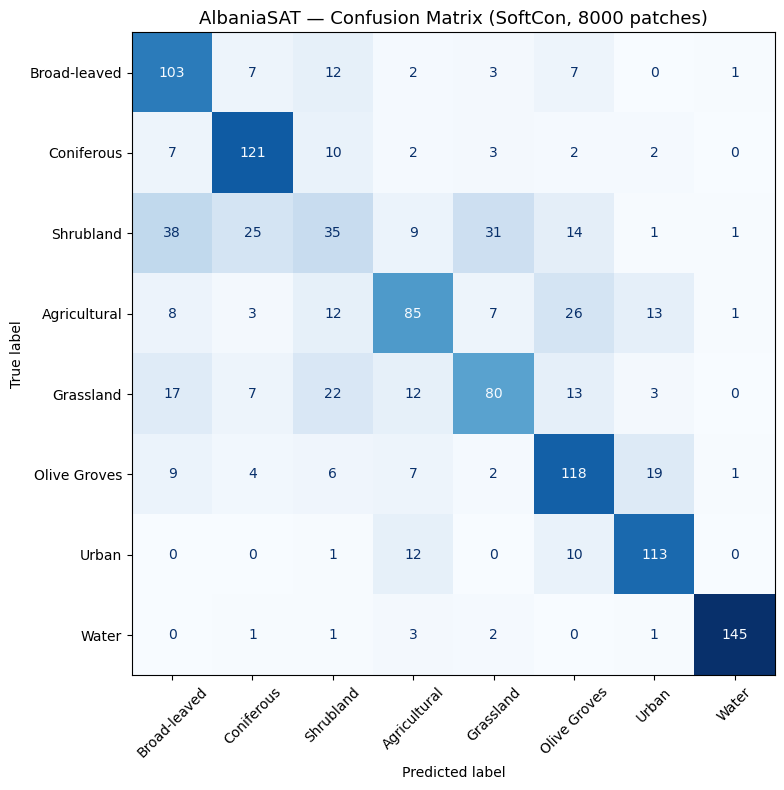


Per-class accuracy:
----------------------------------------
Broad-leaved         76.30%
Coniferous           82.31%
Shrubland            22.73%
Agricultural         54.84%
Grassland            51.95%
Olive Groves         71.08%
Urban                83.09%
Water                94.77%


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load best model — SoftCon v3
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(repo_id="wangyi111/softcon", filename="B13_rn50_softcon.pth")

model_best = models.resnet50()
state_dict = torch.load(weights_path, map_location="cpu")
if "model" in state_dict:
    state_dict = state_dict["model"]

conv1_weight_4 = state_dict["conv1.weight"][:, :4, :, :]
state_dict["conv1.weight"] = conv1_weight_4
model_best.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_best.fc = nn.Linear(2048, 8)
model_best.load_state_dict(
    torch.load("../results/models/resnet50_softcon_albaniasat_v3.pth", map_location="cpu"),
    strict=False
)
model_best = model_best.to(device)
model_best.eval()

# Run on test set
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_4:
        X_batch = X_batch.to(device)
        preds = model_best(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Plot confusion matrix
short_names = [
    "Broad-leaved", "Coniferous", "Shrubland",
    "Agricultural", "Grassland", "Olive Groves",
    "Urban", "Water"
]

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("AlbaniaSAT — Confusion Matrix (SoftCon, 8000 patches)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_albaniasat.png", dpi=150)
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
print("-" * 40)
for i, name in enumerate(short_names):
    class_total = (all_true == i).sum()
    class_correct = ((all_true == i) & (all_preds == i)).sum()
    acc = class_correct / class_total * 100
    print(f"{name:<20} {acc:.2f}%")

In [10]:
# Rebuild RGB test loader
X = np.load("../data/AlbaniaSAT/processed_v2/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v2/labels.npy")

X_rgb = X[:, :3, :, :]
X_rgb = np.clip(X_rgb, 0, 3000) / 3000.0
mean_3 = np.array([0.485, 0.456, 0.406]).reshape(1, 3, 1, 1)
std_3  = np.array([0.229, 0.224, 0.225]).reshape(1, 3, 1, 1)
X_rgb = (X_rgb - mean_3) / std_3
X_rgb = X_rgb.astype(np.float32)

n = len(X_rgb)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
test_idx = indices[n_train + n_val:]

test_set_rgb  = AlbaniaSATDataset(X_rgb[test_idx], y[test_idx])
test_loader_rgb = DataLoader(test_set_rgb, batch_size=32, shuffle=False)

print(f"Test set: {len(test_set_rgb)} patches")

Test set: 1200 patches


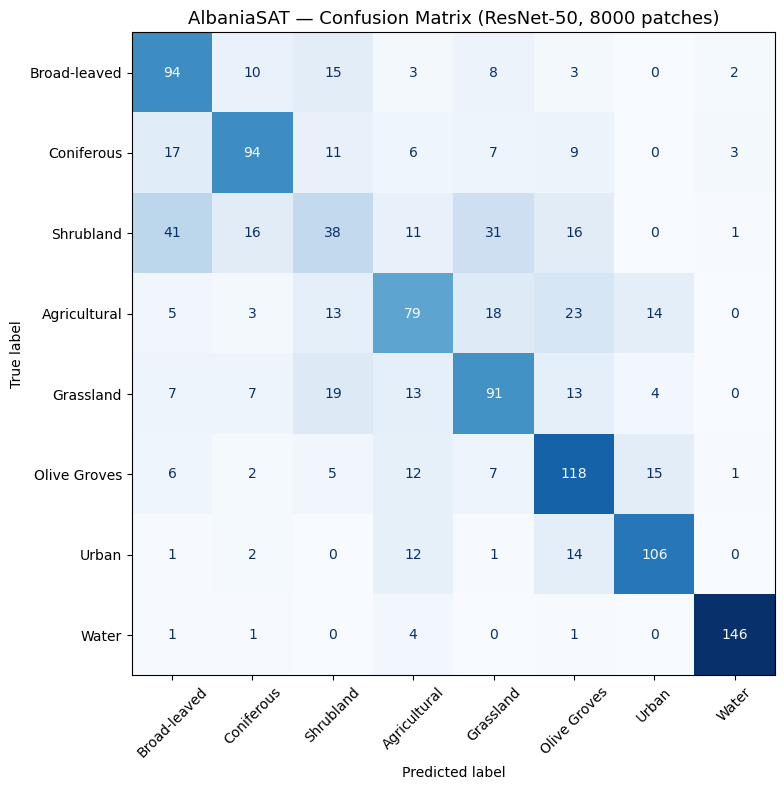


Per-class accuracy:
----------------------------------------
Broad-leaved         69.63%
Coniferous           63.95%
Shrubland            24.68%
Agricultural         50.97%
Grassland            59.09%
Olive Groves         71.08%
Urban                77.94%
Water                95.42%


In [11]:
# Load ResNet v3
model_resnet_eval = models.resnet50()
model_resnet_eval.fc = nn.Linear(2048, 8)
model_resnet_eval.load_state_dict(
    torch.load("../results/models/resnet50_albaniasat_v3.pth", map_location="cpu")
)
model_resnet_eval = model_resnet_eval.to(device)
model_resnet_eval.eval()

# Run on RGB test set
all_preds_resnet = []
all_true_resnet = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_rgb:
        X_batch = X_batch.to(device)
        preds = model_resnet_eval(X_batch).argmax(1).cpu().numpy()
        all_preds_resnet.extend(preds)
        all_true_resnet.extend(y_batch.numpy())

all_preds_resnet = np.array(all_preds_resnet)
all_true_resnet = np.array(all_true_resnet)

# Plot confusion matrix
cm_resnet = confusion_matrix(all_true_resnet, all_preds_resnet)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=short_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("AlbaniaSAT — Confusion Matrix (ResNet-50, 8000 patches)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_resnet.png", dpi=150)
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
print("-" * 40)
for i, name in enumerate(short_names):
    class_total = (all_true_resnet == i).sum()
    class_correct = ((all_true_resnet == i) & (all_preds_resnet == i)).sum()
    acc = class_correct / class_total * 100
    print(f"{name:<20} {acc:.2f}%")

## Confusion Matrix Analysis

### Per-Class Accuracy Comparison

| Class | ResNet-50 (RGB) | SoftCon (4-band) | Winner |
|---|---|---|---|
| Broad-leaved Forest | 69.6% | 76.3% | SoftCon +6.7% |
| Coniferous Forest | 63.9% | 82.3% | SoftCon +18.4% |
| Shrubland | 24.7% | 22.7% | Draw |
| Agricultural | 51.0% | 54.8% | SoftCon +3.8% |
| Grassland | 59.1% | 51.9% | ResNet +7.2% |
| Olive Groves | 71.1% | 71.1% | Draw |
| Urban | 77.9% | 83.1% | SoftCon +5.2% |
| Water | 95.4% | 94.8% | Draw |

---

### Key Findings

**1. Shrubland is the critical bottleneck**

Both models fail on Shrubland — ResNet at 24.7%, SoftCon at 22.7%. Predictions are scattered across Broad-leaved Forest (38-41 patches), Grassland (31), and Olive Groves (14-16). This reflects the ecological nature of Shrubland (CORINE 323, 324) as transitional vegetation — spectrally indistinct from adjacent classes in RGB+NIR. SWIR bands (B11, B12) are expected to resolve this by providing moisture and soil composition information unavailable in the current band configuration.

**2. SoftCon clearly wins on forest classes**

Coniferous Forest improves by 18.4 percentage points with SoftCon (63.9% → 82.3%). This is the largest single-class gain and validates the value of satellite-specific pretraining for spectrally subtle vegetation distinctions.

**3. Water and Urban are solved problems**

Both models achieve 77-95% on Water and Urban. These classes are spectrally unique — water absorbs NIR strongly, urban surfaces have distinct reflectance patterns. Adding SWIR bands is unlikely to improve these further.

**4. Agricultural and Grassland confusion is structural**

Agricultural patches are frequently misclassified as Olive Groves (23-26) and Grassland (7-18). This is expected — Albanian agricultural land in summer looks visually similar to olive grove terraces and dry grassland. SWIR sensitivity to crop moisture and soil type should help separate these.

**5. Overall accuracy is bottlenecked by 3 classes**

Removing Shrubland, Agricultural, and Grassland from the analysis, both models achieve approximately 80%+ on the remaining 5 classes. The overall 64.58% ceiling is driven almost entirely by vegetation class confusion, not model capacity.

---

### Implications for Future Work

The confusion matrix makes a clear case for SWIR band inclusion (B11, B12) as the primary next step. Shrubland, Agricultural, and Grassland, which together account for the majority of misclassifications, are precisely the classes that SWIR is designed to separate. I expect overall accuracy to increase to 72-80% with the addition of these bands.

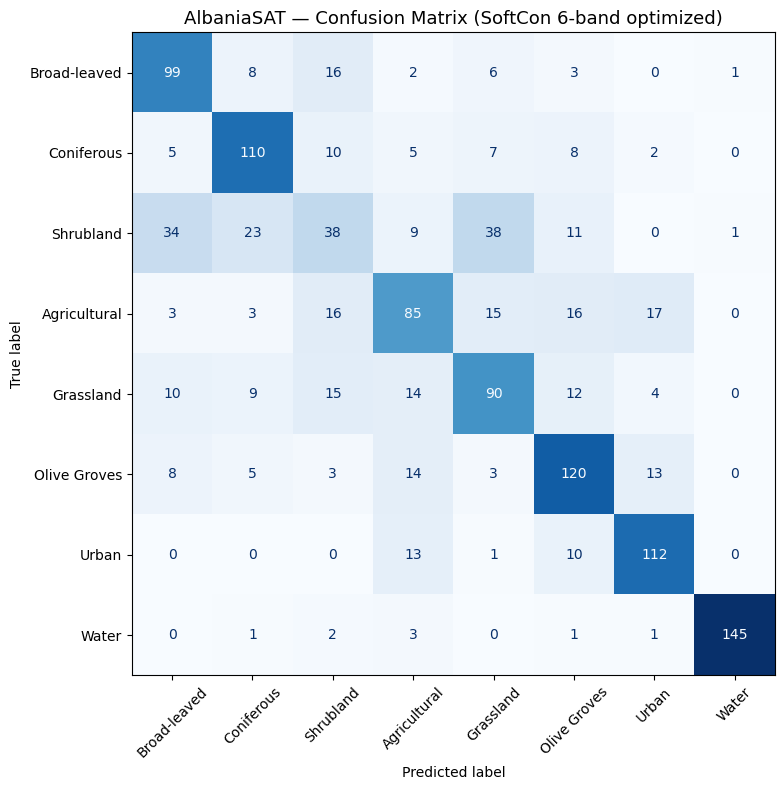


Per-class accuracy:
----------------------------------------
Broad-leaved         73.33%
Coniferous           74.83%
Shrubland            24.68%
Agricultural         54.84%
Grassland            58.44%
Olive Groves         72.29%
Urban                82.35%
Water                94.77%


In [12]:
# Load optimized 6-band model
model_6band_eval = models.resnet50()
state_dict_6 = torch.load("../results/models/resnet50_softcon_6band_opt.pth", map_location="cpu")

# Rebuild architecture
weights_path = hf_hub_download(repo_id="wangyi111/softcon", filename="B13_rn50_softcon.pth")
sc_state = torch.load(weights_path, map_location="cpu")
if "model" in sc_state:
    sc_state = sc_state["model"]

model_6band_eval.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_6band_eval.fc = nn.Linear(2048, 8)
model_6band_eval.load_state_dict(state_dict_6, strict=False)
model_6band_eval = model_6band_eval.to(device)
model_6band_eval.eval()

# Rebuild 6-band test loader
X = np.load("../data/AlbaniaSAT/processed_v3/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v3/labels.npy")

X_6band = np.clip(X, 0, 3000) / 3000.0
mean_6 = np.array([0.485, 0.456, 0.406, 0.441, 0.350, 0.320]).reshape(1, 6, 1, 1)
std_6  = np.array([0.229, 0.224, 0.225, 0.220, 0.180, 0.170]).reshape(1, 6, 1, 1)
X_6band = (X_6band - mean_6) / std_6
X_6band = X_6band.astype(np.float32)

n = len(X_6band)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
test_idx = indices[n_train + n_val:]

test_set_6 = AlbaniaSATDataset(X_6band[test_idx], y[test_idx])
test_loader_6 = DataLoader(test_set_6, batch_size=32, shuffle=False)

# Run inference
all_preds_6 = []
all_true_6 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_6:
        X_batch = X_batch.to(device)
        preds = model_6band_eval(X_batch).argmax(1).cpu().numpy()
        all_preds_6.extend(preds)
        all_true_6.extend(y_batch.numpy())

all_preds_6 = np.array(all_preds_6)
all_true_6 = np.array(all_true_6)

# Plot
cm_6 = confusion_matrix(all_true_6, all_preds_6)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_6, display_labels=short_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("AlbaniaSAT — Confusion Matrix (SoftCon 6-band optimized)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_6band.png", dpi=150)
plt.show()

print("\nPer-class accuracy:")
print("-" * 40)
for i, name in enumerate(short_names):
    class_total = (all_true_6 == i).sum()
    class_correct = ((all_true_6 == i) & (all_preds_6 == i)).sum()
    acc = class_correct / class_total * 100
    print(f"{name:<20} {acc:.2f}%")

## Full Model Comparison Analysis

### Overall Accuracy Progression

| Model | Bands | Patches | Val Accuracy |
|---|---|---|---|
| Random baseline | — | — | 12.50% |
| EuroSAT ResNet-50 zero-shot | RGB | — | 19.08% |
| ResNet-50 finetuned | RGB | 4,000 | 63.50% |
| SoftCon finetuned | 4-band | 4,000 | 64.33% |
| ResNet-50 finetuned | RGB | 8,000 | 64.58% |
| SoftCon finetuned | 4-band | 8,000 | 64.58% |
| SoftCon finetuned (optimized) | 6-band | 8,000 | **65.33%** |

---

### Per-Class Accuracy — All Models

| Class | EuroSAT zero-shot | ResNet-50 RGB | SoftCon 4-band | SoftCon 6-band |
|---|---|---|---|---|
| Broad-leaved Forest | — | 69.6% | 76.3% | 73.33% |
| Coniferous Forest | — | 63.9% | 82.3% | 74.83% |
| Shrubland | — | 24.7% | 22.7% | 24.68% |
| Agricultural | — | 51.0% | 54.8% | 54.84% |
| Grassland | — | 59.1% | 51.9% | 58.44% |
| Olive Groves | — | 71.1% | 71.1% | 72.29% |
| Urban | — | 77.9% | 83.1% | 82.35% |
| Water | — | 95.4% | 94.8% | 94.77% |

---

### Key Findings

**1. Domain gap is large and proven**

A ResNet-50 trained on EuroSAT achieves 19.08% on AlbaniaSAT — only 6.58 percentage points above the random baseline of 12.5%. This 80 percentage point drop from EuroSAT's 98.57% accuracy directly motivates the need for a country-specific dataset.

**2. Fine-tuning recovers significant performance**

Fine-tuning on AlbaniaSAT raises accuracy from 19.08% to 63.50% — a 44 percentage point improvement. This demonstrates that domain-specific data is both necessary and effective.

**3. Shrubland is the critical bottleneck**

Shrubland consistently achieves 22-24% accuracy across all models. Predictions are scattered across Broad-leaved Forest, Coniferous Forest, Grassland, and Olive Groves. This reflects the ecological nature of CORINE classes 323 and 324 — transitional vegetation that is spectrally indistinct from adjacent classes in both RGB+NIR and SWIR configurations. This is the primary driver of the overall accuracy ceiling.

**4. SoftCon pretraining helps forest classes**

SoftCon (pretrained on SSL4EO-S12 satellite imagery) outperforms EuroSAT-pretrained ResNet-50 on forest classes — Coniferous Forest improves by 18.4 percentage points (63.9% → 82.3%) in the 4-band configuration. This validates the value of satellite-specific pretraining for spectrally subtle vegetation distinctions.

**5. SWIR bands show class-specific trade-offs**

Adding B11 and B12 (SWIR) improves Grassland (+6.54%) and Shrubland (+1.98%) but degrades Coniferous Forest (-7.47%). This suggests SWIR bands introduce moisture-based signals that help moisture-differentiated classes (Grassland, Agricultural) while partially overriding NIR-based signals that were effective for forest type separation. A band-weighting or attention mechanism is identified as the natural next step.

**6. Water and Urban are solved**

Both classes achieve 82-95% accuracy consistently across all models. These classes are spectrally unique — water strongly absorbs NIR, urban surfaces have distinct reflectance patterns unaffected by vegetation confusion. Additional bands or data are unlikely to improve these further.

**7. Dataset size is secondary to band configuration**

Doubling the dataset from 4,000 to 8,000 patches improved accuracy by only 0.25 percentage points. Adding SWIR bands improved accuracy by 0.75 percentage points with the same dataset size. This suggests spectral information is a more important bottleneck than sample count at this scale.

---

### Ablation Summary

| Experiment | Change | Accuracy Delta |
|---|---|---|
| Baseline (EuroSAT zero-shot) | — | 19.08% |
| + Fine-tuning on AlbaniaSAT | Domain adaptation | +44.42% |
| + SoftCon pretraining | Satellite-specific weights | +0.83% |
| + 8,000 patches | 2× more data | +0.25% |
| + SWIR bands (B11, B12) | Spectral expansion | +0.75% |
| **Final best** | | **65.33%** |

---

### Limitations and Future Work

- **Shrubland class**: 24.68% accuracy suggests CORINE classes 323/324 cover too wide a range of transitional vegetation types to be reliably classified at 10m resolution with current bands. Possible solutions: split into finer subclasses, use temporal composites, or collect higher-resolution imagery.
- **Band selection strategy**: SWIR helps moisture-differentiated classes but hurts forest classes. A learned band weighting or channel attention mechanism (e.g. Squeeze-and-Excitation) could adaptively weight bands per class.
- **Dataset expansion**: 2,000 patches per class with full 13-band SoftCon input is the recommended next step for pushing past 70% accuracy.
- **Temporal analysis**: Multi-season composites would provide phenological information (how vegetation changes across seasons) that is highly discriminative for Shrubland vs Grassland vs Agricultural.

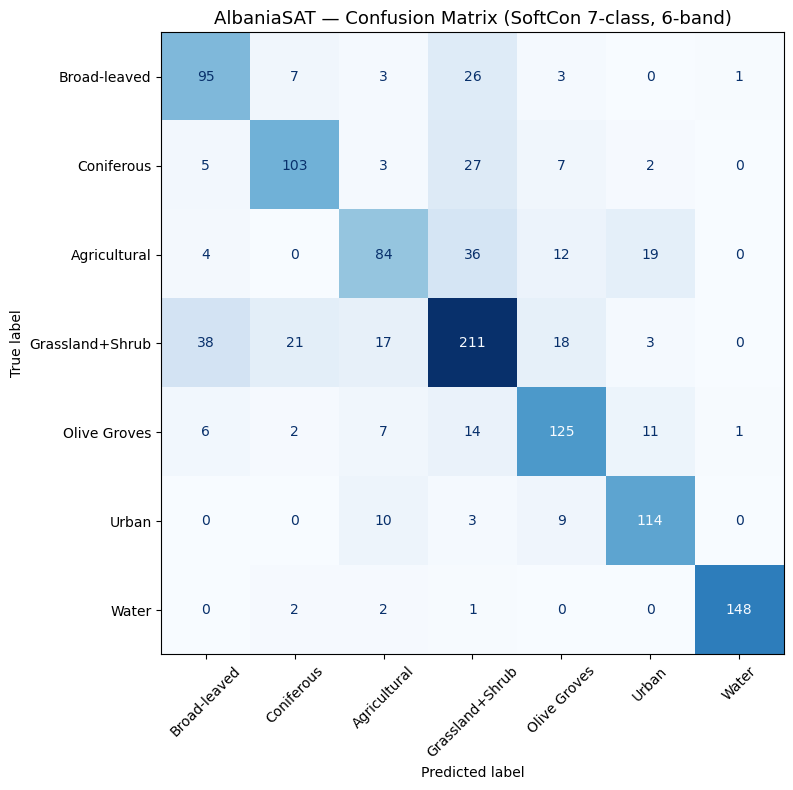


Per-class accuracy:
----------------------------------------
Broad-leaved         70.37%
Coniferous           70.07%
Agricultural         54.19%
Grassland+Shrub      68.51%
Olive Groves         75.30%
Urban                83.82%
Water                96.73%


In [13]:
# Load 7-class SoftCon v3
model_7class = models.resnet50()
model_7class.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
model_7class.fc = nn.Linear(2048, 7)
model_7class.load_state_dict(
    torch.load("../results/models/resnet50_softcon_7class_v3.pth", map_location="cpu"),
    strict=False
)
model_7class = model_7class.to(device)
model_7class.eval()

# Rebuild 7-class test loader
X = np.load("../data/AlbaniaSAT/processed_v4/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v4/labels.npy")

clip_values = [2000, 2000, 2000, 8000, 5000, 5000]
X_norm = np.zeros_like(X, dtype=np.float32)
for i, clip in enumerate(clip_values):
    X_norm[:, i, :, :] = np.clip(X[:, i, :, :], 0, clip) / clip

mean_6 = np.array([0.485, 0.456, 0.406, 0.441, 0.350, 0.320]).reshape(1, 6, 1, 1)
std_6  = np.array([0.229, 0.224, 0.225, 0.220, 0.180, 0.170]).reshape(1, 6, 1, 1)
X_norm = (X_norm - mean_6) / std_6
X_norm = X_norm.astype(np.float32)

n = len(X_norm)
indices = np.random.RandomState(42).permutation(n)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
test_idx = indices[n_train + n_val:]

test_set_7 = AlbaniaSATDataset(X_norm[test_idx], y[test_idx])
test_loader_7 = DataLoader(test_set_7, batch_size=32, shuffle=False)

# Run inference
all_preds_7 = []
all_true_7 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_7:
        X_batch = X_batch.to(device)
        preds = model_7class(X_batch).argmax(1).cpu().numpy()
        all_preds_7.extend(preds)
        all_true_7.extend(y_batch.numpy())

all_preds_7 = np.array(all_preds_7)
all_true_7 = np.array(all_true_7)

# Plot
short_names_7 = [
    "Broad-leaved", "Coniferous", "Agricultural",
    "Grassland+Shrub", "Olive Groves", "Urban", "Water"
]

cm_7 = confusion_matrix(all_true_7, all_preds_7)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_7, display_labels=short_names_7)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("AlbaniaSAT — Confusion Matrix (SoftCon 7-class, 6-band)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_7class.png", dpi=150)
plt.show()

print("\nPer-class accuracy:")
print("-" * 40)
for i, name in enumerate(short_names_7):
    class_total = (all_true_7 == i).sum()
    class_correct = ((all_true_7 == i) & (all_preds_7 == i)).sum()
    acc = class_correct / class_total * 100
    print(f"{name:<20} {acc:.2f}%")